In [1]:
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hiteash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
data = pd.read_csv('sentiment_dataset.csv')

In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@\w+|\#','', text)  # Remove mentions and hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)
    tokens = [word for word in text.split() if word not in stop_words]
    return ' '.join(tokens)

data['clean_text'] = data['text'].apply(preprocess_text)


In [5]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(data['clean_text'])
y = data['sentiment']  # 'positive', 'negative', 'neutral'

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Train Models
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Model Evaluation:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


Logistic Regression Model Evaluation:
Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.35      0.26      0.30        31
           1       0.33      0.26      0.29        31
           2       0.45      0.63      0.53        38

    accuracy                           0.40       100
   macro avg       0.38      0.38      0.37       100
weighted avg       0.38      0.40      0.38       100


Naive Bayes Model Evaluation:
Accuracy: 0.4
              precision    recall  f1-score   support

           0       0.35      0.29      0.32        31
           1       0.36      0.26      0.30        31
           2       0.44      0.61      0.51        38

    accuracy                           0.40       100
   macro avg       0.38      0.38      0.38       100
weighted avg       0.39      0.40      0.39       100


Random Forest Model Evaluation:
Accuracy: 0.36
              precision    recall  f1-score   support

           0       0.30      0.23    

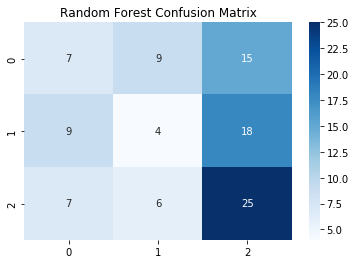

In [8]:
 # Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{name} Confusion Matrix')
plt.show()